In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, confusion_matrix
from collections import Counter
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.linear_model import SGDClassifier

In [12]:
#Read the data
df=pd.read_csv('data/news.csv')

#Get shape and head
df.shape
df.head()

,Unnamed: 0,title,text,label
0,8476,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE
1,10294,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE
2,3608,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL
3,10142,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE
4,875,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL


In [13]:
#DataFlair - Get the labels
labels=df.label
labels.head()

0    FAKE
1    FAKE
2    REAL
3    FAKE
4    REAL
Name: label, dtype: str

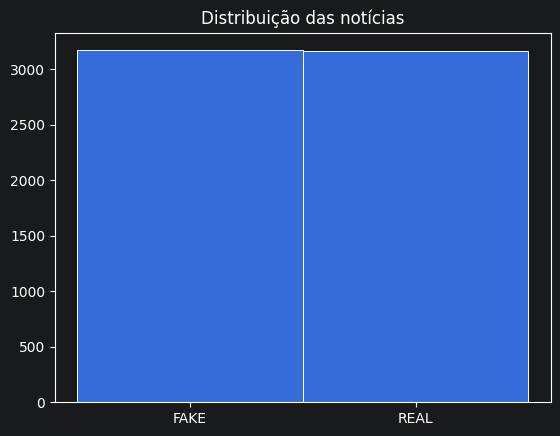

In [14]:
count_labels = df['label'].value_counts()

x = 0.5 + np.arange(2)
y = count_labels.values
fig, ax = plt.subplots()
ax.bar(x, y, width=1, edgecolor="white", linewidth=0.7)
ax.set_xticks(x)
ax.set_xticklabels(['FAKE', 'REAL'])
plt.title('Distribuição das notícias')
plt.show()

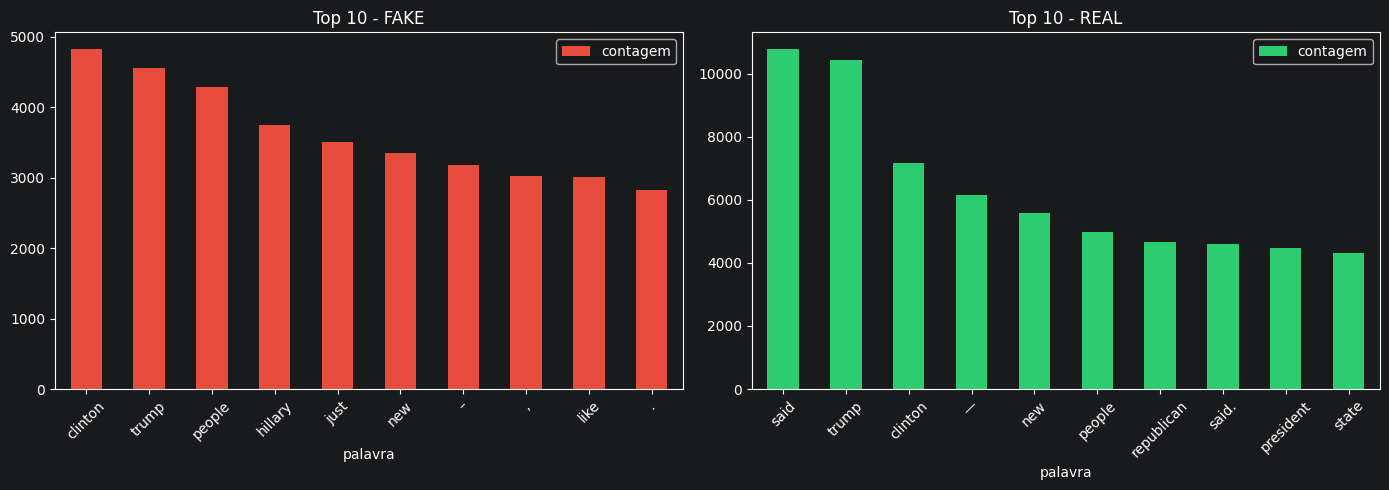

In [15]:
fake_text = ' '.join(df[df['label'] == 'FAKE']['text'].dropna().values)
real_text = ' '.join(df[df['label'] == 'REAL']['text'].dropna().values)

fake_words = Counter(word for word in fake_text.lower().split() if word not in ENGLISH_STOP_WORDS)
real_words = Counter(word for word in real_text.lower().split() if word not in ENGLISH_STOP_WORDS)

df_fake = pd.DataFrame(fake_words.most_common(10), columns=['palavra', 'contagem'])
df_real = pd.DataFrame(real_words.most_common(10), columns=['palavra', 'contagem'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df_fake.plot(kind='bar', x='palavra', y='contagem', title='Top 10 - FAKE', ax=axes[0], color='#e74c3c')
df_real.plot(kind='bar', x='palavra', y='contagem', title='Top 10 - REAL', ax=axes[1], color='#2ecc71')
axes[0].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [16]:
#DataFlair - Split the dataset
df['content'] = 'Title: ' + df['title'].fillna('') + '    [text: ' + df['text'].fillna('') + ']'
print(df['content'].iloc[0][:200])

Title: You Can Smell Hillary’s Fear    [text: Daniel Greenfield, a Shillman Journalism Fellow at the Freedom Center, is a New York writer focusing on radical Islam. 
In the final stretch of the electi


In [18]:
#DataFlair - Initialize a TfidfVectorizer
x_train, x_test, y_train, y_test = train_test_split(
df['content'], labels, test_size=0.2, random_state=7, stratify=labels
)

tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_df=0.7)
tfidf_train = tfidf_vectorizer.fit_transform(x_train)
tfidf_test = tfidf_vectorizer.transform(x_test)

In [19]:
pac = SGDClassifier(loss='hinge', penalty=None, learning_rate='pa1', eta0=1.0, max_iter=50)
pac.fit(tfidf_train, y_train)

y_pred = pac.predict(tfidf_test)
score = accuracy_score(y_test, y_pred)

print(f'Accuracy: {round(score*100, 2)}%')

Accuracy: 94.16%


In [20]:
#DataFlair - Build confusion matrix
confusion_matrix(y_test,y_pred, labels=['FAKE','REAL'])

array([[602,  31],
       [ 43, 591]])

In [21]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.model_selection import cross_val_score

models = {
      'SGD Classifier'     : SGDClassifier(loss='hinge', penalty=None, learning_rate='pa1', eta0=1.0, max_iter=50),
      'Logistic Regression': LogisticRegression(max_iter=1000),
      'Linear SVC'         : LinearSVC(max_iter=2000),
      'Naive Bayes'        : MultinomialNB(),
}

for name, clf in models.items():
      pipeline = Pipeline([
          ('tfidf', TfidfVectorizer(stop_words='english', max_df=0.7)),
          ('clf', clf)
    ])
cv_scores = cross_val_score(pipeline, x_train, y_train, cv=5, scoring='accuracy')
# treino final e predição
pipeline.fit(x_train, y_train)
y_pred = pipeline.predict(x_test)
score = accuracy_score(y_test, y_pred)

print(f'{name}:')
print(f'  CV Accuracy : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'  Test Accuracy: {score:.4f}')

Naive Bayes:
  CV Accuracy : 0.8443 ± 0.0055
  Test Accuracy: 0.8366
